# Omar Mohamed Elmuslimany - Data analytics
# TASK 1 — Exploratory Data Analysis (EDA on Retail Sales Data)

**Objective:** Perform a thorough Exploratory Data Analysis on the retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Tech Stack:** Python, pandas, matplotlib, seaborn, Google Colab

### Checklist
- Load dataset and perform initial inspection
- Descriptive statistics: mean, median, mode, standard deviation
- Monthly and quarterly sales trends
- Customer analysis
- Top 10 best-selling product-level items / closest available field
- Revenue by product category
- Correlation heatmap
- Additional visualization revealing a non-obvious insight
- Written observations after each chart
- At least 3 actionable business recommendations



## 1. Import Libraries

In [19]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Upload and Load the Dataset

In [2]:

# Upload the CSV file from your computer.
uploaded = files.upload()

# Automatically find the uploaded CSV file
csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]

if not csv_files:
    raise FileNotFoundError("No CSV file was uploaded.")

file_name = csv_files[0]
df = pd.read_csv(file_name)

print(f"Loaded file: {file_name}")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())


Saving Retail sales data set.csv to Retail sales data set.csv
Loaded file: Retail sales data set.csv
Dataset shape: 9,994 rows × 11 columns


,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


## 3. Initial Dataset Inspection

In [3]:

print("----- SHAPE -----")
print(df.shape)

print("\n----- COLUMN NAMES -----")
print(df.columns.tolist())

print("\n----- DATA TYPES -----")
display(df.dtypes.to_frame("Data Type"))

print("\n----- NULL VALUES -----")
nulls = df.isnull().sum().to_frame("Missing Values")
nulls["Missing %"] = nulls["Missing Values"] / len(df) * 100
display(nulls)

print("\n----- DUPLICATE ROWS -----")
print("Duplicate rows:", df.duplicated().sum())

print("\n----- UNIQUE VALUES -----")
display(df.nunique().sort_values(ascending=False).to_frame("Unique Values"))


----- SHAPE -----
(9994, 11)

----- COLUMN NAMES -----
['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City', 'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State']

----- DATA TYPES -----


,Data Type
Order ID,object
Customer Name,object
Category,object
Sub Category,object
City,object
Order Date,object
Region,object
Sales,int64
Discount,float64
Profit,float64



----- NULL VALUES -----


,Missing Values,Missing %
Order ID,0,0.00
Customer Name,0,0.00
Category,0,0.00
Sub Category,0,0.00
City,0,0.00
Order Date,0,0.00
Region,0,0.00
Sales,0,0.00
Discount,0,0.00
Profit,0,0.00



----- DUPLICATE ROWS -----
Duplicate rows: 0

----- UNIQUE VALUES -----


,Unique Values
Order ID,9994
Profit,8380
Sales,1989
Order Date,1236
Customer Name,50
Discount,26
City,24
Sub Category,23
Category,7
Region,5



### Observation
The dataset contains **9,994 rows and 11 columns**. There are no missing values or duplicate rows. The main numeric measures are `Sales`, `Discount`, and `Profit`.

The dataset covers retail transactions from **2015 to 2018**. It also contains customer, category, sub-category, city, region, and state information.


## 4. Data Cleaning and Feature Engineering

In [4]:

# Work on a copy so the original dataframe remains available
data = df.copy()

# Convert Order Date safely
data["Order Date"] = pd.to_datetime(data["Order Date"], format="mixed", errors="coerce")

# Check for invalid dates
print("Invalid dates:", data["Order Date"].isna().sum())

# Create useful time dimensions
data["Year"] = data["Order Date"].dt.year
data["Month"] = data["Order Date"].dt.month
data["Month Name"] = data["Order Date"].dt.strftime("%b")
data["Quarter"] = data["Order Date"].dt.to_period("Q").astype(str)
data["Year-Month"] = data["Order Date"].dt.to_period("M").astype(str)

# Profit margin
data["Profit Margin %"] = np.where(
    data["Sales"] != 0,
    data["Profit"] / data["Sales"] * 100,
    np.nan
)

# Validate cleaning
print("Date range:", data["Order Date"].min().date(), "to", data["Order Date"].max().date())
print("Final shape:", data.shape)

display(data.head())


Invalid dates: 0
Date range: 2015-01-03 to 2018-12-30
Final shape: (9994, 17)


,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State,Year,Month,Month Name,Quarter,Year-Month,Profit Margin %
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-11-08,North,1254,0.12,401.28,Tamil Nadu,2017,11,Nov,2017Q4,2017-11,32.00
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-11-08,South,749,0.18,149.80,Tamil Nadu,2017,11,Nov,2017Q4,2017-11,20.00
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-06-12,West,2360,0.21,165.20,Tamil Nadu,2017,6,Jun,2017Q2,2017-06,7.00
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,2016-10-11,South,896,0.25,89.60,Tamil Nadu,2016,10,Oct,2016Q4,2016-10,10.00
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,2016-10-11,South,2355,0.26,918.45,Tamil Nadu,2016,10,Oct,2016Q4,2016-10,39.00


## 5. Descriptive Statistics

In [5]:

numeric_cols = data.select_dtypes(include=np.number).columns

# Mean, median, mode, standard deviation
descriptive = pd.DataFrame({
    "Mean": data[numeric_cols].mean(),
    "Median": data[numeric_cols].median(),
    "Mode": data[numeric_cols].mode().iloc[0],
    "Standard Deviation": data[numeric_cols].std(),
    "Minimum": data[numeric_cols].min(),
    "Maximum": data[numeric_cols].max()
})

display(descriptive)


,Mean,Median,Mode,Standard Deviation,Minimum,Maximum
Sales,"1,496.60","1,498.00","1,259.00",577.56,500.00,"2,500.00"
Discount,0.23,0.23,0.25,0.07,0.10,0.35
Profit,374.94,320.78,198.00,239.93,25.25,"1,120.95"
Year,"2,016.72","2,017.00","2,018.00",1.12,"2,015.00","2,018.00"
Month,7.81,9.00,11.00,3.28,1.00,12.00
Profit Margin %,25.02,25.00,10.00,11.89,5.00,45.00



### Observation
For the original numeric variables, average sales are about **1,496.60**, average discount is about **22.68%**, and average profit is about **374.94** per transaction.

Sales and profit show substantial variation, which means transaction-level performance is not uniform and should be examined by time, category, geography, and customer.


## 6. Overall KPI Summary

In [6]:

total_sales = data["Sales"].sum()
total_profit = data["Profit"].sum()
total_orders = data["Order ID"].nunique()
unique_customers = data["Customer Name"].nunique()
overall_margin = total_profit / total_sales * 100

kpis = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Unique Customers",
        "Overall Profit Margin"
    ],
    "Value": [
        f"{total_sales:,.0f}",
        f"{total_profit:,.2f}",
        f"{total_orders:,}",
        f"{unique_customers:,}",
        f"{overall_margin:.2f}%"
    ]
})

display(kpis)


,KPI,Value
0,Total Sales,"14,956,982"
1,Total Profit,"3,747,121.20"
2,Total Orders,"9,994"
3,Unique Customers,50
4,Overall Profit Margin,25.05%


## 7. Time Series Analysis — Monthly Sales Trend

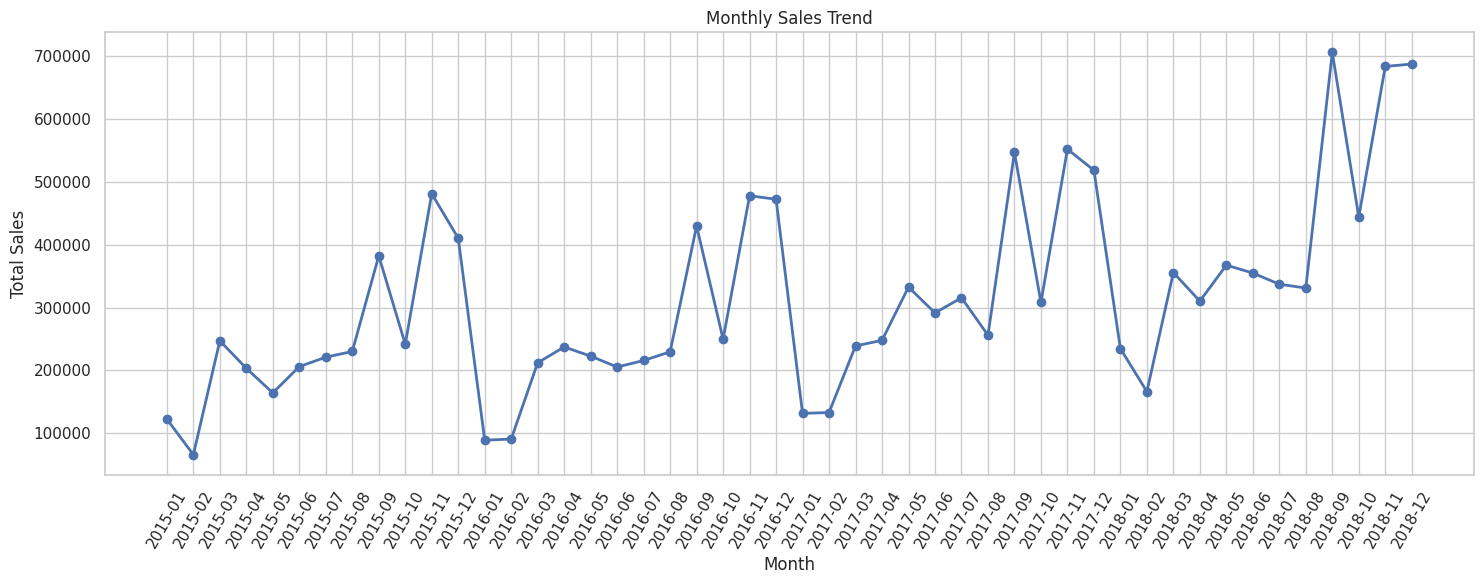

In [7]:

monthly = (
    data.groupby("Year-Month")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

plt.figure(figsize=(15, 6))
plt.plot(monthly["Year-Month"], monthly["Sales"], marker="o", linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()



### Observation
Monthly sales show a clear **upward long-term trend** from 2015 through 2018, with noticeable seasonal peaks toward the end of several years.

The strongest month in the dataset is **September 2018**, with sales of approximately **705,680**. This suggests that the business should prepare inventory and marketing capacity ahead of strong late-year demand.


## 8. Time Series Analysis — Quarterly Sales Trend

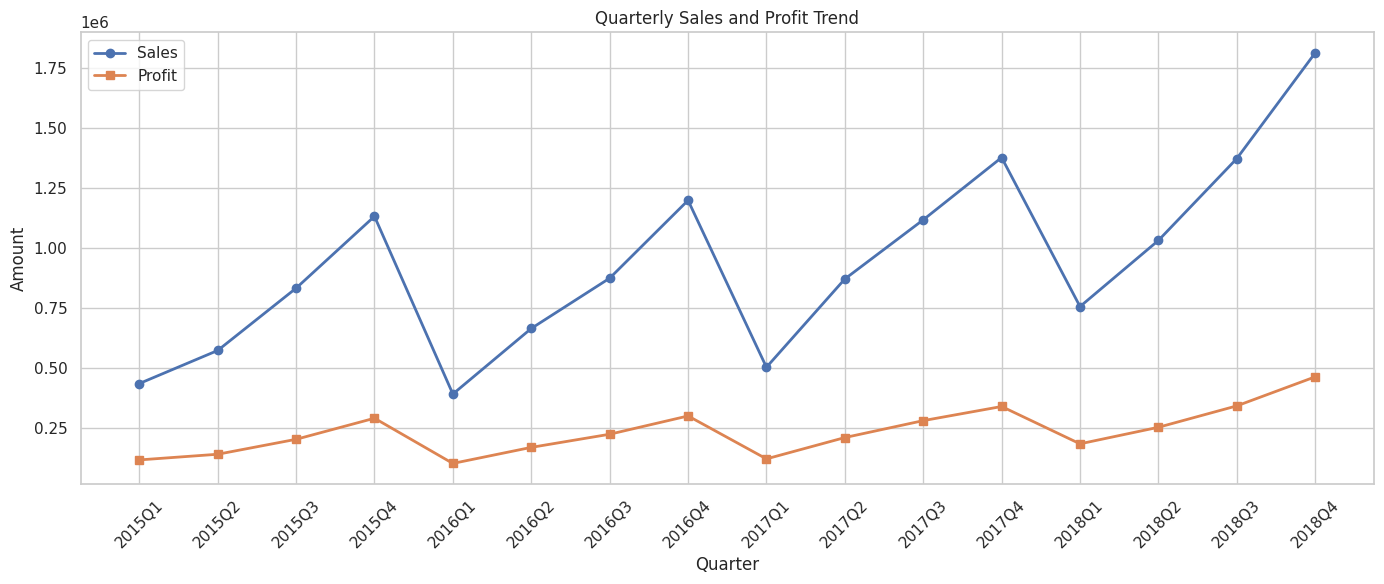

In [8]:

quarterly = (
    data.groupby("Quarter")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

plt.figure(figsize=(14, 6))
plt.plot(quarterly["Quarter"], quarterly["Sales"], marker="o", linewidth=2, label="Sales")
plt.plot(quarterly["Quarter"], quarterly["Profit"], marker="s", linewidth=2, label="Profit")
plt.title("Quarterly Sales and Profit Trend")
plt.xlabel("Quarter")
plt.ylabel("Amount")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Observation
Quarterly performance increases strongly over the four-year period. **Q4 is consistently the strongest quarter**, and **Q4 2018** is the highest-performing quarter with sales of approximately **1.81 million** and profit of approximately **463.8k**.

This indicates a strong opportunity for seasonal campaigns, inventory planning, staffing, and promotional preparation before Q4.


## 9. Customer Analysis

,Orders,Sales,Profit
Customer Name,,,
Krithika,224,334361,"85,633.03"
Amrish,227,333351,"80,191.89"
Verma,218,331665,"79,096.53"
Arutra,218,325720,"87,572.40"
Vidya,215,321798,"86,725.64"
Vinne,203,319565,"79,873.12"
Shah,215,318588,"73,786.22"
Suresh,212,315973,"77,450.88"
Adavan,205,315341,"78,044.29"


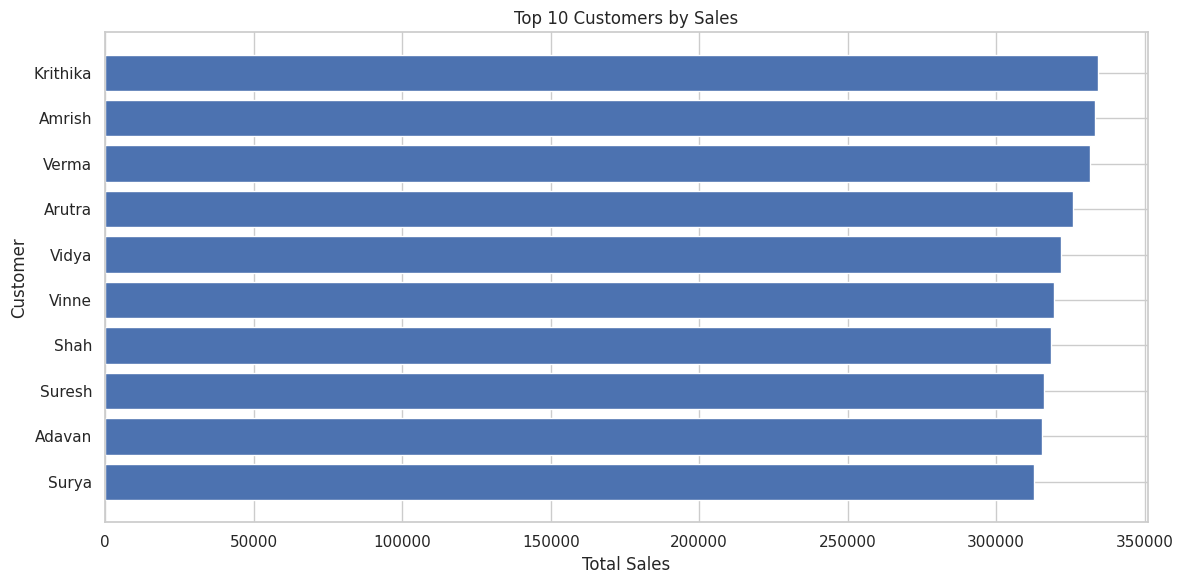

In [9]:

customer_summary = (
    data.groupby("Customer Name")
    .agg(
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .sort_values("Sales", ascending=False)
)

display(customer_summary.head(10))

plt.figure(figsize=(12, 6))
top_customers = customer_summary.head(10).sort_values("Sales")
plt.barh(top_customers.index, top_customers["Sales"])
plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()



### Observation
The dataset contains **50 unique customers**, with several customers generating more than 300k in cumulative sales over the four-year period.

The highest-sales customer is **Krithika**, with approximately **334,361** in sales across **224 orders**. This indicates a strong repeat-customer pattern and suggests that customer retention can be an important revenue driver.



### Customer demographics limitation
The assignment requests age-group and gender analysis. However, this dataset contains **no `Age` or `Gender` columns**.

It would be misleading to infer age or gender from customer names, so those values are **not fabricated**. The customer analysis above uses the available behavioral variables: customer sales, orders, and profit.

If an enriched dataset containing `Age` and `Gender` is provided later, the following charts can be added directly.


In [10]:

# Optional demographic analysis — runs only if Age/Gender exist
age_cols = [c for c in data.columns if c.lower() == "age"]
gender_cols = [c for c in data.columns if c.lower() == "gender"]

if age_cols:
    age_col = age_cols[0]
    bins = [0, 18, 25, 35, 45, 55, 65, 100]
    labels = ["<18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
    data["Age Group"] = pd.cut(data[age_col], bins=bins, labels=labels, right=False)

    plt.figure(figsize=(10, 5))
    data["Age Group"].value_counts().sort_index().plot(kind="bar")
    plt.title("Customer Age Group Distribution")
    plt.xlabel("Age Group")
    plt.ylabel("Customers")
    plt.tight_layout()
    plt.show()
else:
    print("Age analysis skipped: no Age column exists in this dataset.")

if gender_cols:
    gender_col = gender_cols[0]

    plt.figure(figsize=(8, 5))
    data[gender_col].value_counts().plot(kind="bar")
    plt.title("Gender Breakdown")
    plt.xlabel("Gender")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("Gender analysis skipped: no Gender column exists in this dataset.")


Age analysis skipped: no Age column exists in this dataset.
Gender analysis skipped: no Gender column exists in this dataset.


## 10. Product Analysis — Top 10 Best-Selling Items

No Product Name / Product column exists.
Using Sub Category as the closest available product-level proxy.


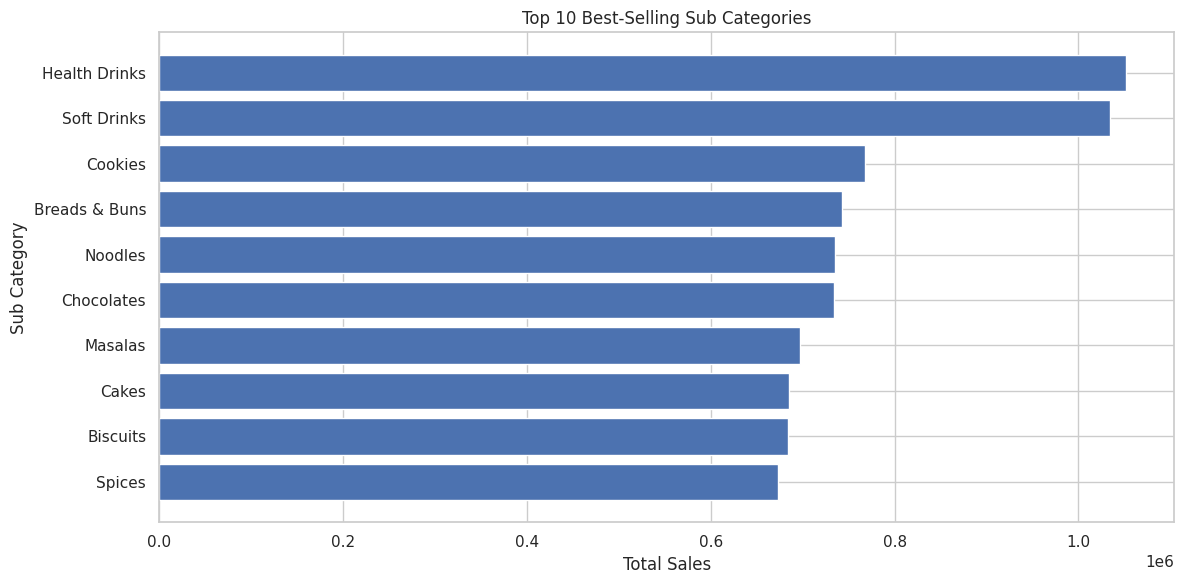

,Sales,Profit,Orders
Sub Category,,,
Health Drinks,1051439,"267,469.79",719
Soft Drinks,1033874,"258,135.97",681
Cookies,768213,"190,643.70",520
Breads & Buns,742586,"190,764.98",502
Noodles,735435,"193,685.81",495
Chocolates,733898,"183,849.34",499
Masalas,697480,"168,999.11",463
Cakes,685612,"168,398.46",452
Biscuits,684083,"169,357.62",459


In [11]:

# Check whether an actual product-level column exists
product_cols = [
    c for c in data.columns
    if any(word in c.lower() for word in ["product name", "product", "item"])
]

if product_cols:
    product_col = product_cols[0]
    product_summary = (
        data.groupby(product_col)
        .agg(
            Sales=("Sales", "sum"),
            Profit=("Profit", "sum"),
            Orders=("Order ID", "nunique")
        )
        .sort_values("Sales", ascending=False)
    )

    top10_products = product_summary.head(10)

    plt.figure(figsize=(12, 6))
    plt.barh(top10_products.index[::-1], top10_products["Sales"][::-1])
    plt.title(f"Top 10 Best-Selling {product_col}s")
    plt.xlabel("Total Sales")
    plt.ylabel(product_col)
    plt.tight_layout()
    plt.show()

else:
    print("No Product Name / Product column exists.")
    print("Using Sub Category as the closest available product-level proxy.")

    product_summary = (
        data.groupby("Sub Category")
        .agg(
            Sales=("Sales", "sum"),
            Profit=("Profit", "sum"),
            Orders=("Order ID", "nunique")
        )
        .sort_values("Sales", ascending=False)
    )

    top10_products = product_summary.head(10)

    plt.figure(figsize=(12, 6))
    plt.barh(top10_products.index[::-1], top10_products["Sales"][::-1])
    plt.title("Top 10 Best-Selling Sub Categories")
    plt.xlabel("Total Sales")
    plt.ylabel("Sub Category")
    plt.tight_layout()
    plt.show()

display(top10_products)



### Observation
There is no individual `Product Name` field in the supplied dataset, so `Sub Category` is used as the closest available product-level proxy.

The highest-selling sub-category is **Health Drinks**, with sales of approximately **1.05 million**, followed by **Soft Drinks** at approximately **1.03 million**. These are important candidates for inventory availability and promotional attention.


## 11. Revenue by Product Category

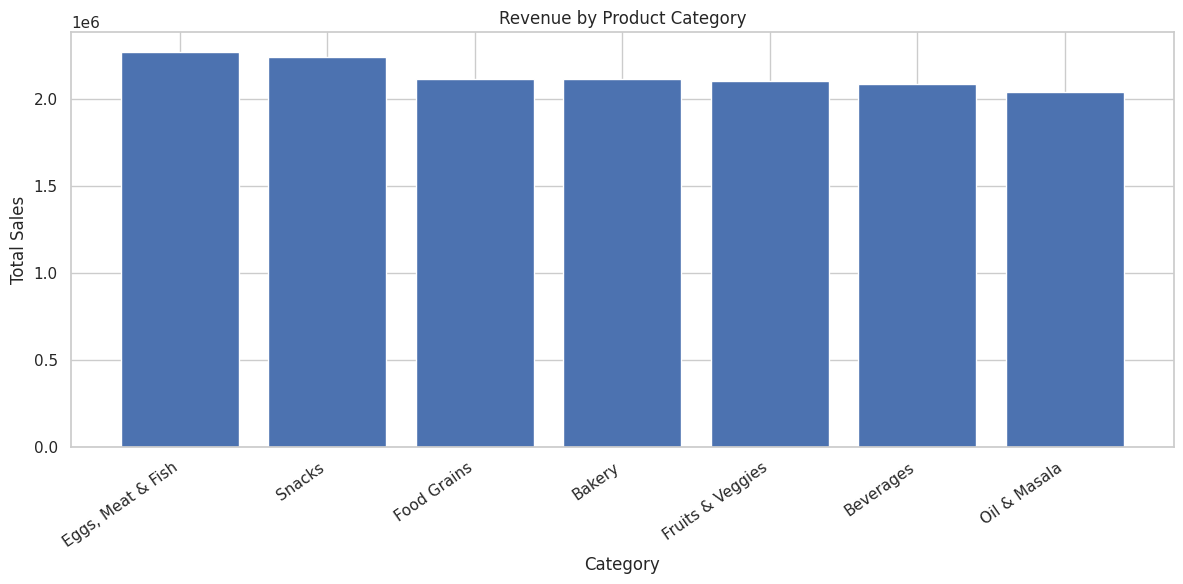

,Sales,Profit,Orders
Category,,,
"Eggs, Meat & Fish",2267401,"567,357.22",1490
Snacks,2237546,"568,178.85",1514
Food Grains,2115272,"529,162.64",1398
Bakery,2112281,"528,521.06",1413
Fruits & Veggies,2100727,"530,400.38",1418
Beverages,2085313,"525,605.76",1400
Oil & Masala,2038442,"497,895.29",1361


In [12]:

category_summary = (
    data.groupby("Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .sort_values("Sales", ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(category_summary.index, category_summary["Sales"])
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

display(category_summary)



### Observation
**Eggs, Meat & Fish** is the highest-revenue category at approximately **2.27 million**, followed closely by **Snacks** at approximately **2.24 million**.

The categories are relatively balanced overall, so the business is not dependent on a single category. However, **Oil & Masala** has the lowest total sales and the lowest category profit margin (about **24.43%**), making it a potential area for pricing, assortment, or promotion review.


## 12. Correlation Heatmap

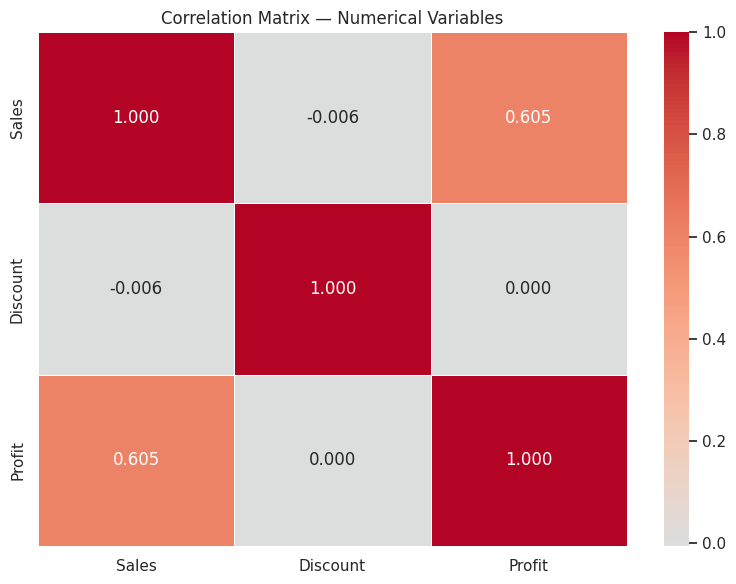

,Sales,Discount,Profit
Sales,1.00,-0.01,0.61
Discount,-0.01,1.00,0.00
Profit,0.61,0.00,1.00


In [13]:

correlation_cols = ["Sales", "Discount", "Profit"]
corr = data[correlation_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Matrix — Numerical Variables")
plt.tight_layout()
plt.show()

display(corr)



### Observation
The strongest relationship is between **Sales and Profit (about 0.605)**, which is logical: higher sales generally create higher profit.

Interestingly, **Discount has almost zero linear correlation with Sales (-0.006) and Profit (approximately 0.000)** at the transaction level. This suggests that discount percentage alone does not explain sales or profit variation in this dataset.


## 13. Additional Visualization — Discount Level vs Profitability

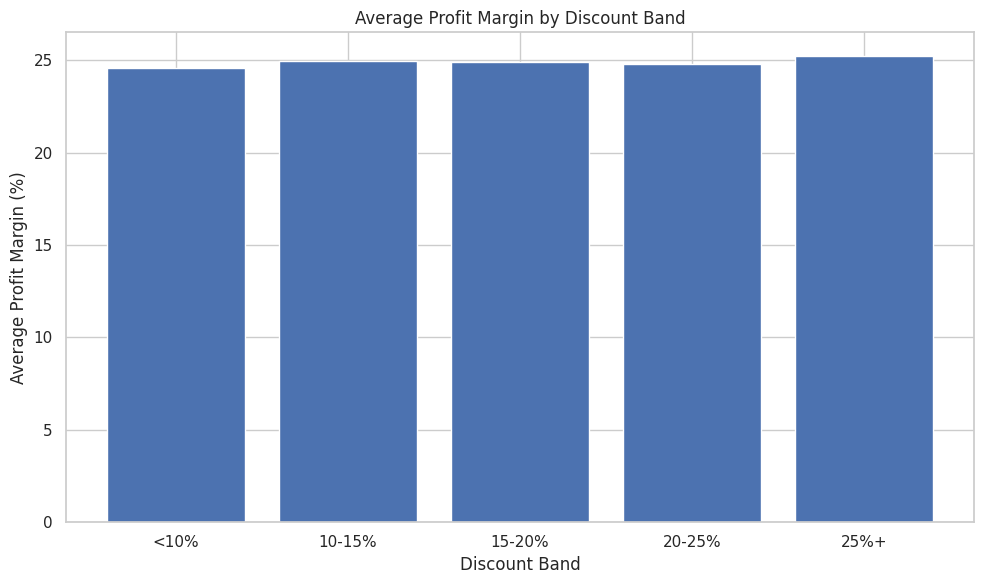

,Orders,Sales,Profit,Avg_Profit_Margin
Discount Band,,,,
<10%,366,532943,"132,451.16",24.59
10-15%,1841,2768867,"694,518.39",24.94
15-20%,1875,2816273,"699,520.53",24.94
20-25%,2012,3021719,"751,465.26",24.81
25%+,3900,5817180,"1,469,165.86",25.25


In [14]:

# Create discount bands to investigate a non-obvious business pattern
bins = [-0.001, 0.10, 0.15, 0.20, 0.25, 1.00]
labels = ["<10%", "10-15%", "15-20%", "20-25%", "25%+"]

data["Discount Band"] = pd.cut(
    data["Discount"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

discount_analysis = (
    data.groupby("Discount Band", observed=False)
    .agg(
        Orders=("Order ID", "count"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Avg_Profit_Margin=("Profit Margin %", "mean")
    )
)

plt.figure(figsize=(10, 6))
plt.bar(
    discount_analysis.index.astype(str),
    discount_analysis["Avg_Profit_Margin"]
)
plt.title("Average Profit Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Average Profit Margin (%)")
plt.tight_layout()
plt.show()

display(discount_analysis)



### Non-obvious insight
Despite the wide range of discounts, average profit margin stays surprisingly close to **25% across the discount bands**. The correlation heatmap also showed almost no linear relationship between discount and profit.

This means discount percentage by itself is **not enough to evaluate promotion effectiveness**. Management should evaluate discounts together with product mix, order volume, revenue, and profit rather than assuming that a higher discount automatically causes lower profitability.


## 14. Regional Analysis — Customer Behaviour by Region

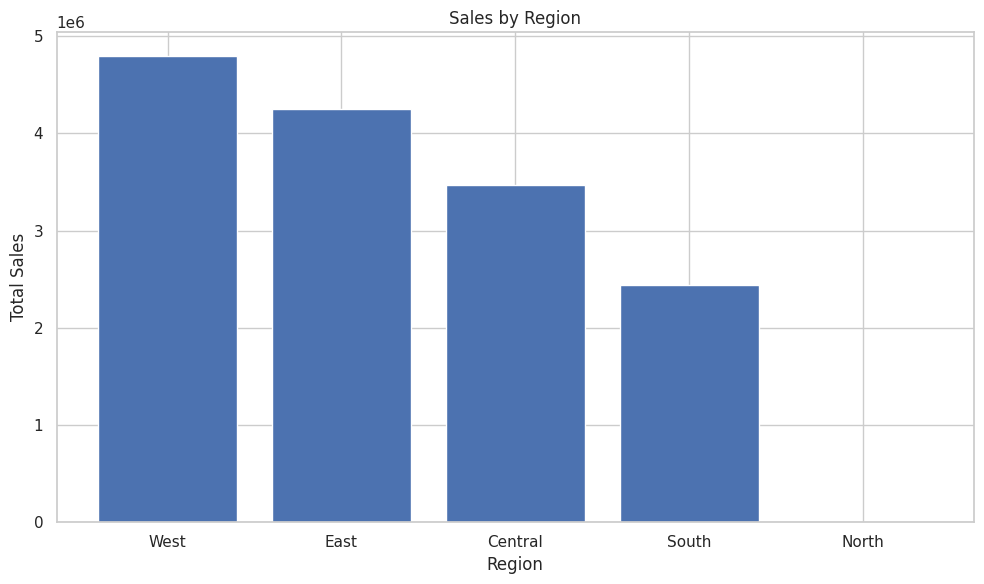

,Orders,Sales,Profit
Region,,,
West,3203,4798743,"1,192,004.61"
East,2848,4248368,"1,074,345.58"
Central,2323,3468156,"856,806.84"
South,1619,2440461,"623,562.89"
North,1,1254,401.28


In [15]:

region_summary = (
    data.groupby("Region")
    .agg(
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .sort_values("Sales", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(region_summary.index, region_summary["Sales"])
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

display(region_summary)



### Observation
The **West region** generates the highest sales at approximately **4.80 million**, representing about **32% of total sales**.

The East region is second at approximately **4.25 million**. These two regions should receive particular attention when allocating inventory, sales resources, and marketing budgets.


## 15. Year-over-Year Sales Growth

,Sales,Profit,Orders,YoY Sales Growth %
Year,,,,
2015,2975599,"752,529.11",1993,NaN
2016,3131959,"797,192.99",2102,5.25
2017,3871912,"953,216.22",2587,23.63
2018,4977512,"1,244,182.88",3312,28.55


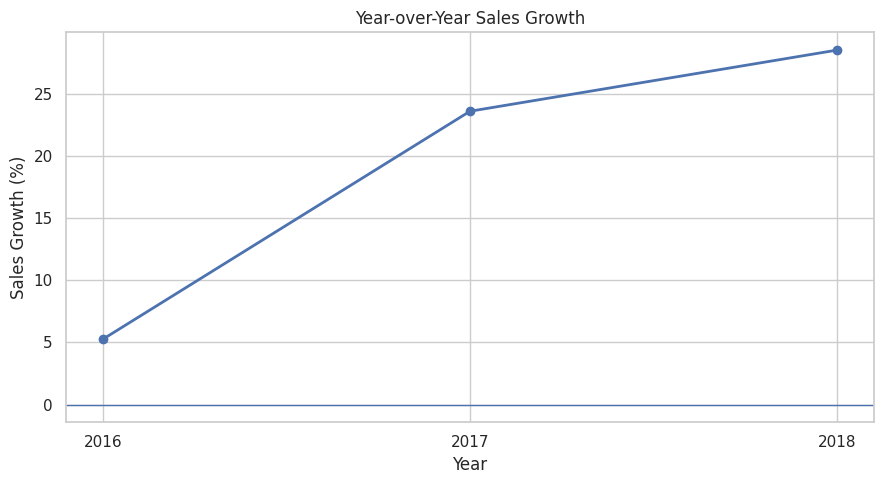

In [16]:

yearly = (
    data.groupby("Year")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
)

yearly["YoY Sales Growth %"] = yearly["Sales"].pct_change() * 100

display(yearly)

plt.figure(figsize=(9, 5))
plt.plot(yearly.index.astype(str), yearly["YoY Sales Growth %"], marker="o", linewidth=2)
plt.title("Year-over-Year Sales Growth")
plt.xlabel("Year")
plt.ylabel("Sales Growth (%)")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()



### Observation
Sales growth accelerates over time:

- **2016:** approximately 5.3% growth
- **2017:** approximately 23.6% growth
- **2018:** approximately 28.6% growth

The business therefore shows strong expansion momentum, with 2018 becoming the strongest sales year.


## 16. Final Business Insights

In [17]:

# Automatically print a compact set of key findings
top_category = category_summary.index[0]
top_category_sales = category_summary.iloc[0]["Sales"]

top_subcategory = product_summary.index[0]
top_subcategory_sales = product_summary.iloc[0]["Sales"]

top_region = region_summary.index[0]
top_region_sales = region_summary.iloc[0]["Sales"]

best_month = monthly.loc[monthly["Sales"].idxmax()]
best_quarter = quarterly.loc[quarterly["Sales"].idxmax()]
best_year = yearly.loc[yearly["Sales"].idxmax()]

print("KEY FINDINGS")
print("-" * 60)
print(f"Total sales: {total_sales:,.0f}")
print(f"Total profit: {total_profit:,.2f}")
print(f"Overall profit margin: {overall_margin:.2f}%")
print(f"Top category: {top_category} ({top_category_sales:,.0f} sales)")
print(f"Top sub-category proxy: {top_subcategory} ({top_subcategory_sales:,.0f} sales)")
print(f"Top region: {top_region} ({top_region_sales:,.0f} sales)")
print(f"Best month: {monthly.loc[monthly['Sales'].idxmax(), 'Year-Month']}")
print(f"Best quarter: {best_quarter['Quarter']}")
print(f"Best year: {best_year.name}")


KEY FINDINGS
------------------------------------------------------------
Total sales: 14,956,982
Total profit: 3,747,121.20
Overall profit margin: 25.05%
Top category: Eggs, Meat & Fish (2,267,401 sales)
Top sub-category proxy: Health Drinks (1,051,439 sales)
Top region: West (4,798,743 sales)
Best month: 2018-09
Best quarter: 2018Q4
Best year: 2018



# 17. Conclusion — Actionable Business Recommendations

### Recommendation 1 — Prepare aggressively for Q4 demand
Q4 is consistently the strongest quarter, with **Q4 2018 reaching about 1.81M in sales**. Increase inventory availability, staffing, logistics capacity, and promotional planning before Q4.

### Recommendation 2 — Protect and grow the strongest categories and sub-categories
**Eggs, Meat & Fish** is the highest-revenue category, while **Health Drinks** is the leading sub-category by sales. Prioritize stock availability and targeted campaigns for these high-performing areas.

### Recommendation 3 — Focus on customer retention
The dataset has only **50 unique customers**, while individual customers place many repeat orders. Build loyalty/retention initiatives, personalized offers, and repeat-purchase campaigns for high-value customers.

### Recommendation 4 — Prioritize the West and East regions
The **West** region contributes about **32% of total sales**, with the East region also generating a large share. Allocate inventory and sales/marketing resources according to regional demand.

### Recommendation 5 — Do not judge discounts in isolation
Discount percentage has almost no linear correlation with sales or profit in this dataset, and average margins remain close to 25% across discount bands. Evaluate promotions using **sales, profit, margin, product mix, and order volume together**.

### Final EDA Summary
The dataset shows a business with **strong growth from 2015 to 2018**, pronounced **Q4 seasonality**, concentrated performance in several categories/sub-categories, and meaningful repeat-customer behavior. The most important operational opportunities are seasonal planning, customer retention, regional resource allocation, and smarter evaluation of promotional discounts.



## 18. Export Cleaned Data and Summary Tables

This final section saves the cleaned dataset and important analysis tables so they can be reused in Excel, Power BI, Tableau, or a portfolio project.


In [18]:

# Save cleaned dataset
data.to_csv("retail_sales_cleaned.csv", index=False)

# Save major summary tables
category_summary.to_csv("category_summary.csv")
region_summary.to_csv("region_summary.csv")
customer_summary.to_csv("customer_summary.csv")
product_summary.to_csv("subcategory_summary.csv")
monthly.to_csv("monthly_summary.csv", index=False)
quarterly.to_csv("quarterly_summary.csv", index=False)
yearly.to_csv("yearly_summary.csv")

print("Files created successfully:")
print("• retail_sales_cleaned.csv")
print("• category_summary.csv")
print("• region_summary.csv")
print("• customer_summary.csv")
print("• subcategory_summary.csv")
print("• monthly_summary.csv")
print("• quarterly_summary.csv")
print("• yearly_summary.csv")


Files created successfully:
• retail_sales_cleaned.csv
• category_summary.csv
• region_summary.csv
• customer_summary.csv
• subcategory_summary.csv
• monthly_summary.csv
• quarterly_summary.csv
• yearly_summary.csv
